In [5]:
import os                     # for working with folders and file names
import cv2                    # main computer vision library (OpenCV)
import numpy as np            # numerical operations (we may need later)
import matplotlib.pyplot as plt  # for showing images in the notebook

# this is the folder that has all 2x2 puzzles
puzzle_folder = "Gravity Falls/puzzle_2x2"

# this folder will store the tiles BEFORE preprocessing
raw_tiles_folder = "tiles_2x2/raw"

# this folder will store the tiles AFTER preprocessing
prep_tiles_folder = "tiles_2x2/prep"

# create the two output folders if they do not exist yet
os.makedirs(raw_tiles_folder, exist_ok=True)
os.makedirs(prep_tiles_folder, exist_ok=True)

# make a sorted list of all puzzle image files (0.jpg, 1.jpg, ...)
puzzle_files = sorted(
    f for f in os.listdir(puzzle_folder)
    if f.lower().endswith((".jpg", ".png", ".jpeg"))
)

print("Number of 2x2 puzzles:", len(puzzle_files))
print("First few files:", puzzle_files[:5])


Number of 2x2 puzzles: 110
First few files: ['0.jpg', '1.jpg', '10.jpg', '100.jpg', '101.jpg']


In [ ]:


tile_records = []

# pipeline
for puzzle_index, puzzle_name in enumerate(puzzle_files):

    print("\n==============================")
    print("Processing puzzle index:", puzzle_index, "file:", puzzle_name)
    print("==============================")

    # load all puzzle
    puzzle_path = os.path.join(puzzle_folder, puzzle_name)

    puzzle_bgr = cv2.imread(puzzle_path)                      # BGR 
    puzzle_rgb = cv2.cvtColor(puzzle_bgr, cv2.COLOR_BGR2RGB)  # RGB for display

    # size of the full puzzle
    h, w, c = puzzle_rgb.shape
    print("  puzzle size:", h, "x", w, "channels:", c)

    # because this is a 2x2 puzzle: 2 rows, 2 columns of tiles
    tile_h = h // 2
    tile_w = w // 2
    print("  tile size:  ", tile_h, "x", tile_w)

    # cut puxzle into 4 tiles
    for r in range(2):         # row index: 0, 1
        for c in range(2):     # col index: 0, 1

            print("\n  Tile (row, col) =", (r, c))

            # coordinates of this tile in the full image
            y1 = r * tile_h
            y2 = (r + 1) * tile_h
            x1 = c * tile_w
            x2 = (c + 1) * tile_w

            # crop the tile (color, RGB)
            tile_rgb = puzzle_rgb[y1:y2, x1:x2]

            # save raw
            base_name = f"puzzle_{puzzle_index:03d}_r{r}_c{c}"
            raw_name  = base_name + "_raw.png"
            raw_path  = os.path.join(raw_tiles_folder, raw_name)

            cv2.imwrite(raw_path, cv2.cvtColor(tile_rgb, cv2.COLOR_RGB2BGR))

            # preprocess the tile
            # convert to grayscale
            tile_gray = cv2.cvtColor(tile_rgb, cv2.COLOR_RGB2GRAY)

            # median filter 3*3
            tile_med = cv2.medianBlur(tile_gray, 3)


            final_tile = tile_med  # our preprocessed piece

            # save pereprocessed
            prep_name = base_name + "_prep.png"
            prep_path = os.path.join(prep_tiles_folder, prep_name)

            cv2.imwrite(prep_path, final_tile)

            # record this tile ( later use)
            tile_records.append({
                "puzzle_index": puzzle_index,
                "puzzle_file":  puzzle_name,
                "row":          r,
                "col":          c,
                "raw_path":     raw_path,
                "prep_path":    prep_path,
            })

print("\nTOTAL tiles processed:", len(tile_records))



Processing puzzle index: 0 file: 0.jpg
  puzzle size: 224 x 224 channels: 3
  tile size:   112 x 112

  Tile (row, col) = (0, 0)

  Tile (row, col) = (0, 1)

  Tile (row, col) = (1, 0)

  Tile (row, col) = (1, 1)

Processing puzzle index: 1 file: 1.jpg
  puzzle size: 224 x 224 channels: 3
  tile size:   112 x 112

  Tile (row, col) = (0, 0)

  Tile (row, col) = (0, 1)

  Tile (row, col) = (1, 0)

  Tile (row, col) = (1, 1)

Processing puzzle index: 2 file: 10.jpg
  puzzle size: 224 x 224 channels: 3
  tile size:   112 x 112

  Tile (row, col) = (0, 0)

  Tile (row, col) = (0, 1)

  Tile (row, col) = (1, 0)

  Tile (row, col) = (1, 1)

Processing puzzle index: 3 file: 100.jpg
  puzzle size: 224 x 224 channels: 3
  tile size:   112 x 112

  Tile (row, col) = (0, 0)

  Tile (row, col) = (0, 1)

  Tile (row, col) = (1, 0)

  Tile (row, col) = (1, 1)

Processing puzzle index: 4 file: 101.jpg
  puzzle size: 224 x 224 channels: 3
  tile size:   112 x 112

  Tile (row, col) = (0, 0)

  Tile (


Showing puzzle index: 0 with 4 tiles


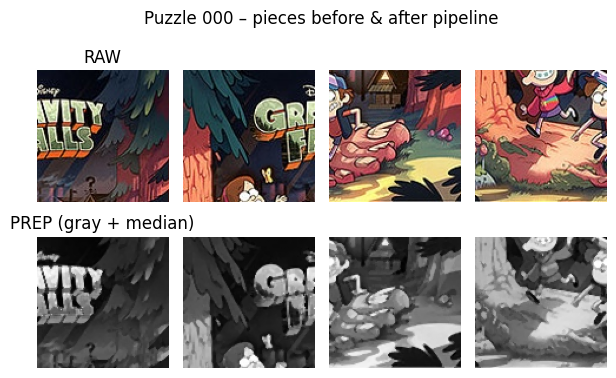


Showing puzzle index: 1 with 4 tiles


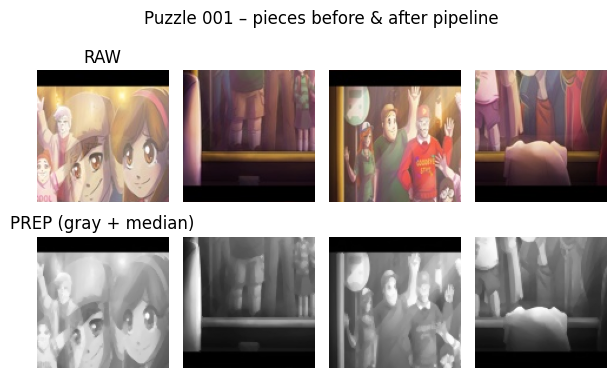


Showing puzzle index: 2 with 4 tiles


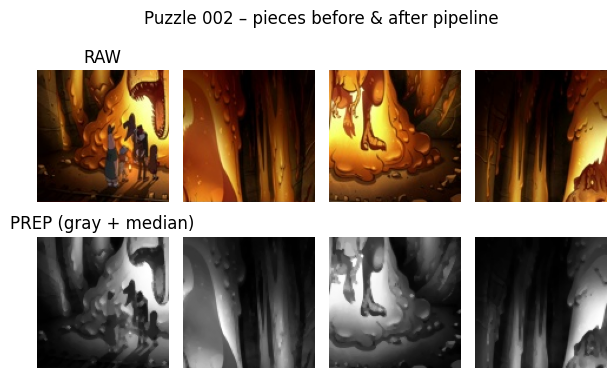


Showing puzzle index: 3 with 4 tiles


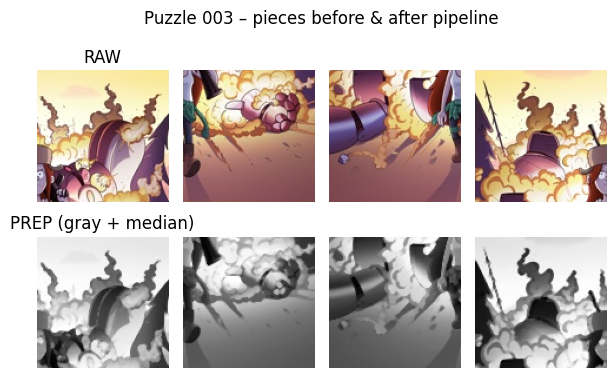


Showing puzzle index: 4 with 4 tiles


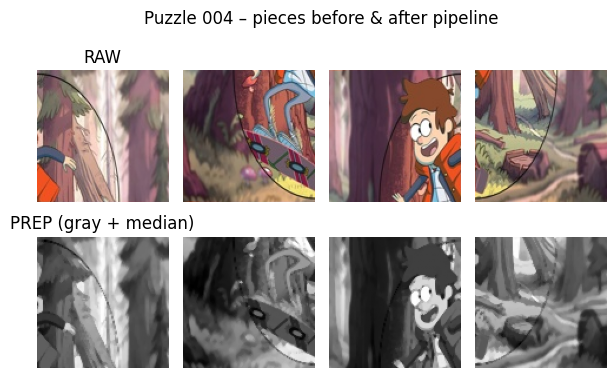

In [15]:
# visualize some results
num_puzzles_to_show = 5

for check_index in range(num_puzzles_to_show):

    # get all tiles that belong to this puzzle index
    records = [rec for rec in tile_records if rec["puzzle_index"] == check_index]
    records = sorted(records, key=lambda rec: (rec["row"], rec["col"]))

    if len(records) == 0:
        print("No tiles found for puzzle index", check_index)
        continue

    print("\nShowing puzzle index:", check_index, "with", len(records), "tiles")

    plt.figure(figsize=(6, 4))

    for i, rec in enumerate(records):
        # load raw
        raw_bgr = cv2.imread(rec["raw_path"])
        raw_rgb = cv2.cvtColor(raw_bgr, cv2.COLOR_BGR2RGB)

        # load preprocessed
        prep_gray = cv2.imread(rec["prep_path"], cv2.IMREAD_GRAYSCALE)

        # top row: RAW
        plt.subplot(2, 4, i + 1)
        plt.imshow(raw_rgb)
        plt.axis("off")
        if i == 0:
            plt.title("RAW")

        # bottom row: PREP
        plt.subplot(2, 4, i + 1 + 4)
        plt.imshow(prep_gray, cmap="gray")
        plt.axis("off")
        if i == 0:
            plt.title("PREP (gray + median)")

    plt.suptitle(f"Puzzle {check_index:03d} – pieces before & after pipeline")
    plt.tight_layout()
    plt.show()
